# Threshold for OT
OT seems to struggle with Hi-C maps at higher resolutions. To test whether this is due to too many values being fed to POT or purely due to the resolution, we'll test if setting a threshold will alleviate these errors. The following will be tested:
- What value is acceptable as a threshold? Will be determined by plotting the data and determining how much can be trimmed.
- How do the OT values of the threshold data compare to OT values from non-threshold data?
- How does the threshold affect the feasibility of OT at higher resolutions?

## Importing Data

In [11]:
### Importing Cooler Files ###
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import numpy as np
import matplotlib.pyplot as plt
import ot
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, generate_related_contact_map, bin_contact_map, get_cool_name, hic_ot_source_to_targets

# Importing data
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic'
coolers = import_cool_dir(data_dir, 1_000_000)

# Extracting chromosome 1
chr1s = []
map_names = []
for clr in coolers:
    chr1s.append(fetch_region(clr, '1'))
    map_names.append(get_cool_name(clr).split("_")[1])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
### Binning First Chromosomes ###
chr1s_binned = []
for chr1 in chr1s:
    chr1s_binned.append(bin_contact_map(chr1, 4))

## Extracting Non-Zero Values and Plotting

In [13]:
### Extracting Cumulative Non-Zero Values ###
values_max_norm = []

for chr1 in chr1s_binned:
    mask = np.triu(chr1, k=1) > 0
    values = chr1[mask]
    values = values / values.max()  # Maximum normalization to make values more comparable
    values_max_norm.extend(values)

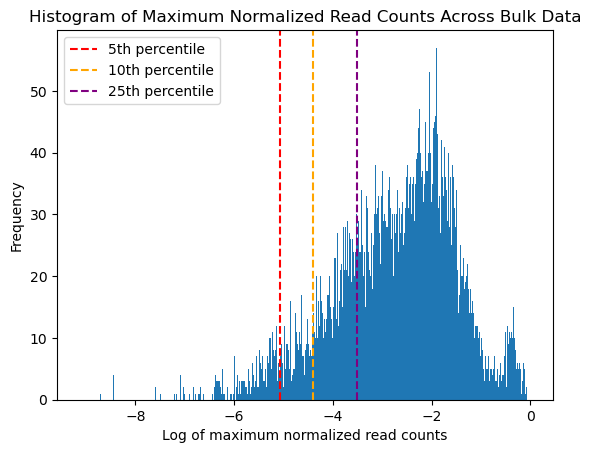

In [14]:
### Plotting Values ###
# Calculating percentiles for threshold candidates
percentile_5 = np.percentile(values_max_norm, 5)
percentile_10 = np.percentile(values_max_norm, 10)
percentile_25 = np.percentile(values_max_norm, 25)

# Plotting
plt.hist(np.log(values_max_norm), bins=1000)
plt.axvline(np.log(percentile_5), linestyle='--', color='red', label="5th percentile")
plt.axvline(np.log(percentile_10), linestyle='--', color='orange', label="10th percentile")
plt.axvline(np.log(percentile_25), linestyle='--', color='purple', label="25th percentile")
plt.xlabel("Log of maximum normalized read counts")
plt.ylabel("Frequency")
plt.title("Histogram of Maximum Normalized Read Counts Across Bulk Data")
plt.legend()
plt.show()

From this graph, thresholds at the 5th and 10th percentile seem quite reasonable.

## Function to Extract Coords and Values Above Threshold

In [15]:
### Defining Function ###
def hic_mask_threshold(matrix : np.ndarray, value : float, type : str = "raw",
                       norm : str = "none"):
    '''
        Returns the values and corresponding coordinates of a Hi-C
        matrix that are above a given threshold (raw of percentile based).

        Parameters
        ----------
        matrix : np.ndarray
            Symmetrical matrix corresponding to a Hi-C map.
        value : float
            The value used to determine the threshold.
        type : str
            The kind of threshold to be set.
            Options include 'raw' and 'percentile'.
        norm : str
            Type of normalization to use. Options include "none",
            "max" and "sum".
        
        Returns
        -------
        matrix_values : np.ndarray
            A list of values in the input matrix above the threshold.
        matrix_coords : np.ndarray
            A list of coordinates for all values in matrix_values.
    '''
    types = ["raw", "percentile"]
    norms = ["none", "max", "sum"]
    
    # Errors
    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError("Provided matrix is not symmetrical")
    if type not in types:
        raise ValueError(f"Provided threshold type is invalid: {type}")
    if norm not in norms:
        raise ValueError(f"Provided normalization type is invalid: {norm}")
    
    # Extracting raw value for percentile
    if type == "percentile":
        value = np.percentile(matrix, value)
    
    # Extracting points
    matrix_mask = np.triu(matrix, k=1) > value
    matrix_coords = np.column_stack(np.where(matrix_mask))
    matrix_values = matrix[matrix_mask]

    # Applying normalization
    if norm == "max":
        matrix_values = matrix_values / matrix_values.max()
    if norm == "sum":
        matrix_values = matrix_values / matrix_values.sum()

    return matrix_values, matrix_coords

In [16]:
### Testing function ###
# No threshold
values_max_norm_test = []
for chr1 in chr1s_binned:
    values_max_norm_test.extend(hic_mask_threshold(chr1, 0, type="raw", norm="max")[0])

assert(values_max_norm == values_max_norm_test)

# 10th percentile
values_max_norm_10th = []
for chr1 in chr1s_binned:
    values_max_norm_10th.extend(hic_mask_threshold(chr1, 10, type="percentile", norm="max")[0])

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_99098/3336763600.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


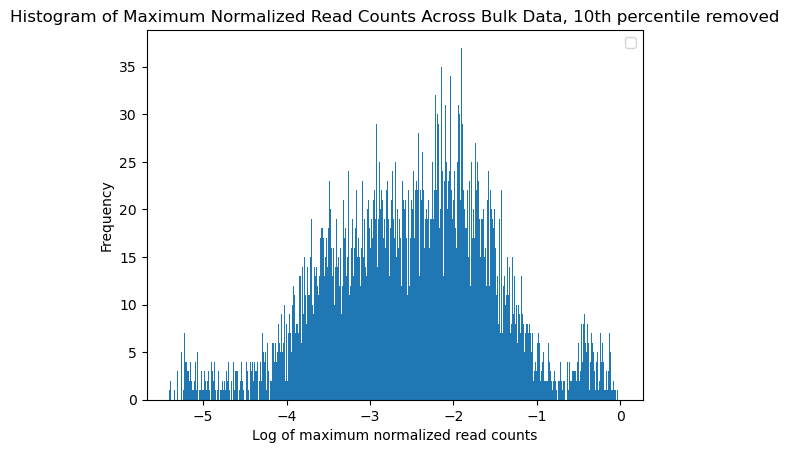

In [17]:
### Plotting 10th Percentile ###
plt.hist(np.log(values_max_norm_10th), bins=1000)
plt.xlabel("Log of maximum normalized read counts")
plt.ylabel("Frequency")
plt.title("Histogram of Maximum Normalized Read Counts Across Bulk Data, 10th percentile removed")
plt.legend()
plt.show()

Due to the nature of the implementation, this is not exactly the same as the percentile indicated before, as now the 10th percentile of each individual dataset is removed rather than the 10th percentile of the overall dataset.

## Testing Exact OT on Threshold Data
Now that we have a working threshold function, we can test how this function affects OT results.

In [18]:
### Generating Related Maps ###
clp1_binned = chr1s_binned[9]
print(clp1_binned)
similarities = [0.99, 0.9, 0.75, 0.5, 0.25, 0.1, 0.01, 0.001]
clp_related = []

for sim in similarities:
    clp_related.append(generate_related_contact_map(clp1_binned, base_decay=0.75, similarity=sim, seed = 106))

[[ 9821  4944  1092 ...    49    56    42]
 [ 4944 62169 11040 ...   256   221   224]
 [ 1092 11040 61143 ...   274   253   167]
 ...
 [   49   256   274 ... 68907 11661  3415]
 [   56   221   253 ... 11661 73715  9282]
 [   42   224   167 ...  3415  9282 65765]]


In [19]:
### Prepping Data for OT ###
percentiles = [0, 5, 10, 25, 50, 75, 90]

source_values_list = []
source_coords_list = []
target_values_list = []
target_coords_list = []

for percentile in percentiles:
    # Source
    if percentile == 0:
        source_values, source_coords = hic_mask_threshold(clp1_binned, percentile, type="raw", norm="max")
        print(source_values.sum())
    else:
        source_values, source_coords = hic_mask_threshold(clp1_binned, percentile, type="percentile", norm="max")
        print(source_values.sum())
    source_values_list.append(source_values)
    source_coords_list.append(source_coords)

    # Target
    target_values = []
    target_coords = []
    for target in clp_related:
        if percentile == 0:
            values, coords = hic_mask_threshold(target, percentile, type="raw", norm="max")
        else:
            values, coords = hic_mask_threshold(target, percentile, type="percentile", norm="max")
        values = values * (source_values.sum() / values.sum())
        target_values.append(values)
        target_coords.append(coords)
    target_values_list.append(target_values)
    target_coords_list.append(target_coords)

134.84383843581168
134.47637423891607
133.51076237029415
128.29963124946403
111.79169882514364
79.5754223479976
47.59051539319098


In [20]:
### Exact OT ###
ot_values_list = []

for source_values, source_coords, target_values, target_coords in zip(
    source_values_list, source_coords_list, target_values_list, target_coords_list
    ):
    ot_values = []

    for values, coords in zip(target_values, target_coords):
        ot_value = ot.solve_sample(source_coords, coords, source_values, values).value
        ot_values.append(ot_value)
    ot_values_list.append(ot_values)

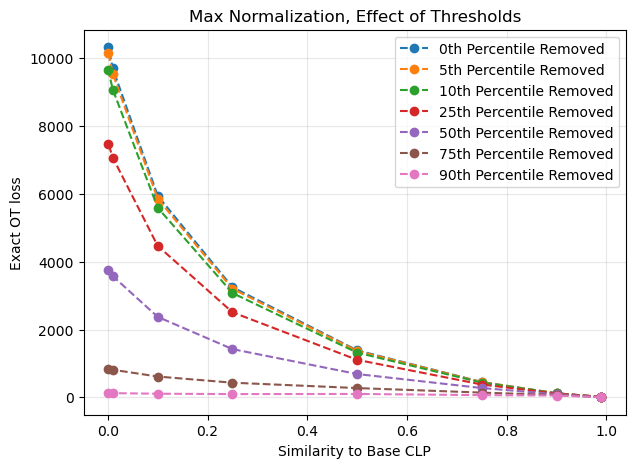

In [21]:
### Visualizing ###
plt.figure(figsize=(7, 5))
for ot_values, percentile in zip(ot_values_list, percentiles):
    plt.plot(similarities, ot_values, 'o--', label=f"{percentile}th Percentile Removed")
plt.xlabel("Similarity to Base CLP")
plt.ylabel("Exact OT loss")
plt.title("Max Normalization, Effect of Thresholds")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

From this graph, it seems like the general relationship is still relatively well-defined when removing the 25th percentile. Further trimming leads to less distinction between datasets.

## Testing UOT on Threshold Data

In [ ]:
# Prepping data for OT
percentiles = [0, 5, 10, 25, 50, 75, 90]

source_values_list_uot = []
source_coords_list_uot = []
target_values_list_uot = []
target_coords_list_uot = []

for percentile in percentiles:
    # Source
    if percentile == 0:
        source_values_uot, source_coords_uot = hic_mask_threshold(clp1_binned, percentile, type="raw", norm="max")
    else:
        source_values_uot, source_coords_uot = hic_mask_threshold(clp1_binned, percentile, type="percentile", norm="max")
    source_values_list_uot.append(source_values_uot)
    source_coords_list_uot.append(source_coords_uot)

    # Target
    target_values_uot = []
    target_coords_uot = []
    
    for target in clp_related:
        if percentile == 0:
            values, coords = hic_mask_threshold(target, percentile, type="raw", norm="max")
        else:
            values, coords = hic_mask_threshold(target, percentile, type="percentile", norm="max")
        target_values_uot.append(values)
        target_coords_uot.append(coords)
    
    target_values_list_uot.append(target_values_uot)
    target_coords_list_uot.append(target_coords_uot)

In [ ]:
### UOT ###
ot_values_list_uot = []
unbalanced = 5e-1

for source_values, source_coords, target_values, target_coords in zip(
    source_values_list_uot, source_coords_list_uot, target_values_list_uot, target_coords_list_uot
    ):
    ot_values_uot = []

    for values, coords in zip(target_values, target_coords):
        ot_value_uot = ot.solve_sample(source_coords, coords, source_values, values, unbalanced=unbalanced).value
        ot_values_uot.append(ot_value_uot)
    ot_values_list_uot.append(ot_values_uot)

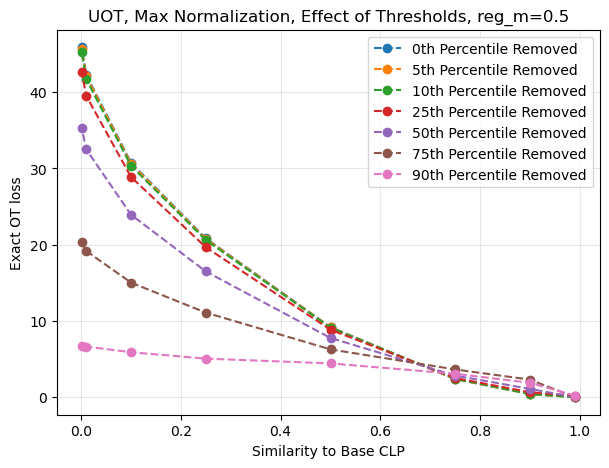

In [ ]:
### Visualizing ###
plt.figure(figsize=(7, 5))
for ot_values, percentile in zip(ot_values_list_uot, percentiles):
    plt.plot(similarities, ot_values, 'o--', label=f"{percentile}th Percentile Removed")
plt.xlabel("Similarity to Base CLP")
plt.ylabel("UOT loss")
plt.title(f"UOT, Max Normalization, Effect of Thresholds, reg_m={unbalanced}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

While hard to see from this graph, the graph is roughly the same up until the removal of the 50th percentile, where the graph starts deforming around higher similarities. This supports that the 25th percentile seems to be the sweetspot.

## Testing General Function
To make future work easier, I wrote a general function to compare a source distribution to many targets. To test if this function works correctly, we will compare the data from above to the data from the function

In [24]:
# Exact OT
ot_values_list_test = []

for percentile in percentiles:
    if percentile == 0:
        ot_values_list_test.append(hic_ot_source_to_targets(clp1_binned, clp_related, percentile, 'raw', 'max'))
    else:
        ot_values_list_test.append(hic_ot_source_to_targets(clp1_binned, clp_related, percentile, 'percentile', 'max'))

print('Function results are identical:', ot_values_list_test == ot_values_list)

Function results are identical: True


In [25]:
# Exact OT
ot_values_list_uot_test = []

for percentile in percentiles:
    if percentile == 0:
        ot_values_list_uot_test.append(hic_ot_source_to_targets(clp1_binned, clp_related, percentile, 'raw', 'max', unbalanced))
    else:
        ot_values_list_uot_test.append(hic_ot_source_to_targets(clp1_binned, clp_related, percentile, 'percentile', 'max', unbalanced))

print('Function results are identical:', ot_values_list_uot_test == ot_values_list_uot)

NameError: name 'unbalanced' is not defined

Both tests return true, validating the general function